# Diabetes Classification and Clustering Analysis

This notebook explores a diabetes dataset using both supervised classification and unsupervised clustering. The workflow includes data preparation, exploratory analysis, feature assessment, model training, clustering, and a comparison of the two approaches.

## 1. Libraries and dependencies

Import the libraries needed for data ingestion and handling, visualization, preprocessing, modeling, and evaluation and error analysis


In [241]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans, HDBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, adjusted_rand_score, normalized_mutual_info_score

## 2. Data ingestion

Load the dataset and inspect the first rows, schema, and sample records to confirm the structure before any cleaning or modeling.


In [242]:
df = pd.read_csv("Dataset of Diabetes .csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


## 3. Data cleaning and preprocessing

Remove unneeded columns, normalize labels, handle duplicates, and inspect invalid values so the data is ready for modeling.


In [244]:
df = df.drop(columns=['ID', 'No_Pation'],axis = 1)

In [245]:
df.head(5)

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [246]:
df.describe()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


In [247]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())


Gender:
['F' 'M' 'f']

AGE:
[50 26 33 45 48 43 32 31 30 49 42 39 41 44 47 36 38 46 35 40 59 51 57 63
 25 60 77 54 34 55 28 56 52 69 73 61 58 53 66 68 62 64 67 70 79 76 65 75
 20 71]

Urea:
[ 4.7    4.5    7.1    2.3    2.     2.6    3.6    4.4    3.3    3.
  4.6    3.5    5.5    5.9    2.2    3.8   13.5    5.     5.3    4.
  3.2    4.8    4.2    4.3    7.5    5.6    6.     3.4    4.1    2.7
  5.7    3.7    3.1    2.4    5.4    2.1    3.9    2.8    7.6    6.8
  5.2    6.3    6.6    5.8   10.     9.6    7.3   22.     6.1   17.1
  7.7    1.8    5.1    9.1    8.5    6.5    4.16   8.7   20.8    1.2
  2.9   14.1    9.9    9.3   11.7    7.8    4.9    8.    20.     4.66
 14.     6.2    5.66   6.66   3.66  10.5    7.     6.4   10.4    1.9
  3.33   8.6    2.5   14.5    8.9    6.7   11.3   11.     0.5   13.2
 24.    10.3    7.4    6.833 11.1   13.3    7.9    7.2    1.1    9.
 14.9    4.33   9.2   11.2   38.9    6.9   26.4    8.1    8.2    8.8  ]

Cr:
[ 46  62  24  50  47  67  28  55  53  42  54 

In [248]:
df['Gender'] = df['Gender'].astype(str).str.upper().map({'M': 0, 'F': 1}).fillna(df['Gender'])
df['CLASS'] = df['CLASS'].astype(str).str.strip()

print(df['Gender'].value_counts())
print(df['CLASS'].value_counts())

Gender
0    565
1    435
Name: count, dtype: int64
CLASS
Y    844
N    103
P     53
Name: count, dtype: int64


In [249]:
print("No. of duplicate rows:", df.duplicated().sum())

No. of duplicate rows: 174


In [250]:
df= df.drop_duplicates()
print("No. of duplicate rows:", df.duplicated().sum())

No. of duplicate rows: 0


In [251]:
numeric_cols = df.select_dtypes(include=['number']).columns

print(df[numeric_cols].describe().T)

        count       mean        std   min     25%     50%   75%     max
Gender  826.0   0.439467   0.496623   0.0   0.000   0.000   1.0    1.00
AGE     826.0  53.490315   8.808427  20.0  51.000  55.000  59.0   79.00
Urea    826.0   5.184677   3.077831   0.5   3.615   4.600   5.7   38.90
Cr      826.0  69.024213  59.557108   6.0  48.000  59.000  73.0  800.00
HbA1c   826.0   8.326344   2.602589   0.9   6.500   8.100  10.2   16.00
Chol    826.0   4.898208   1.328812   0.0   4.000   4.800   5.6   10.30
TG      826.0   2.399370   1.456850   0.3   1.500   2.015   3.0   13.80
HDL     826.0   1.211804   0.679610   0.2   0.900   1.100   1.3    9.90
LDL     826.0   2.590061   1.132863   0.3   1.700   2.500   3.3    9.90
VLDL    826.0   1.774576   3.517931   0.1   0.700   1.000   1.5   35.00
BMI     826.0  29.459274   4.996676  19.0  26.000  30.000  33.0   47.75


In [252]:
invalid_cols = []
for col in numeric_cols:
    if col == 'Gender' : 
        continue
    if (df[col] <= 0).any():
        invalid_cols.append(col)
        print(f"\nInvalid values in {col}:")
        print(df.loc[df[col]<=0])


Invalid values in Chol:
    Gender  AGE  Urea   Cr  HbA1c  Chol   TG  HDL  LDL  VLDL   BMI CLASS
99       0   77   5.0  106    5.4   0.0  2.8  0.8  1.8   0.7  19.0     N


In [253]:
for col in invalid_cols:
    df = df[df[col] > 0]

## 4. Exploratory data analysis

Explore class balance, distributions, relationships, and correlation patterns to understand the healthcare features and the signals driving the target class.


In [254]:
class_percentage = df['CLASS'].value_counts(normalize=True) * 100
print(f"\nPercentage of each class:\n{class_percentage}")


Percentage of each class:
CLASS
Y    83.636364
N    11.515152
P     4.848485
Name: proportion, dtype: float64


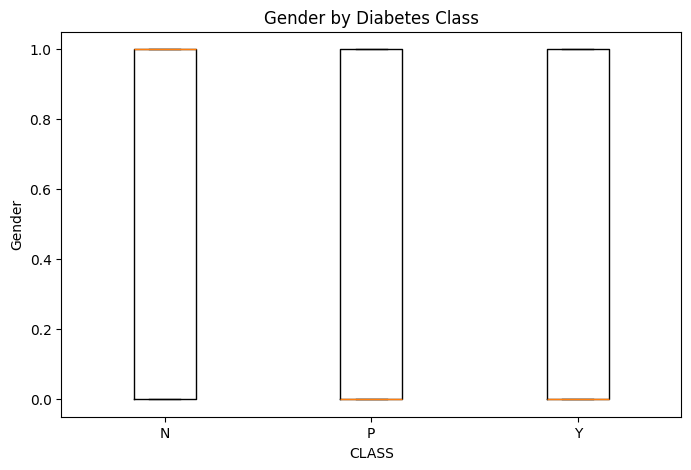

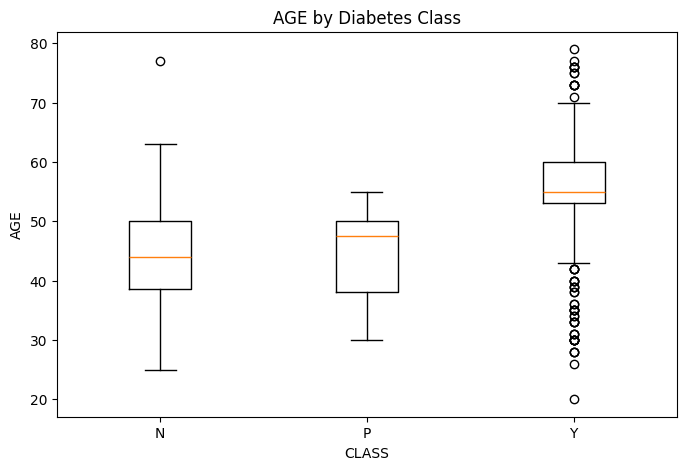

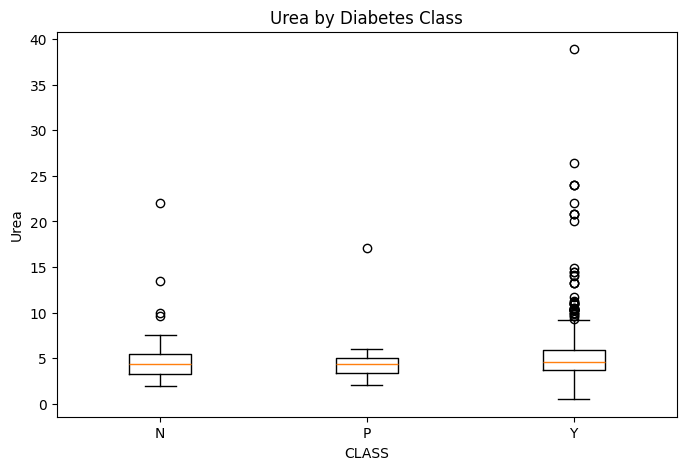

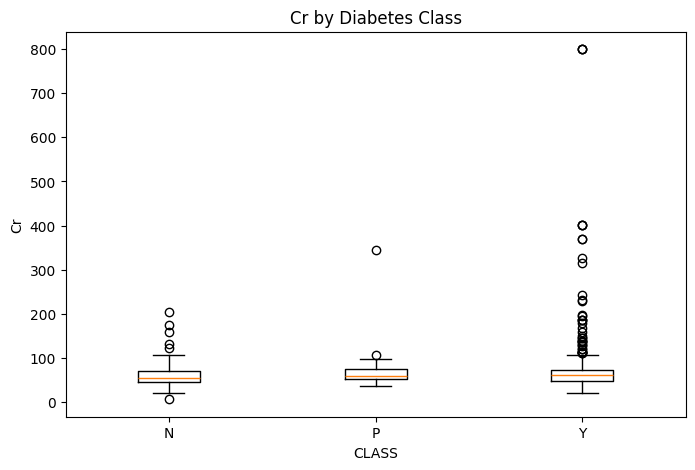

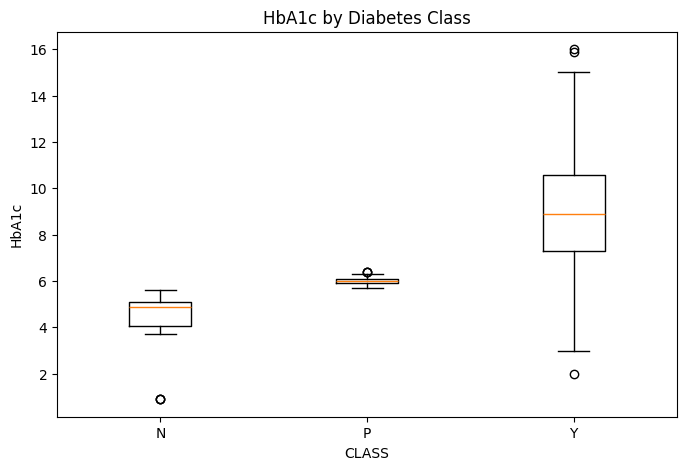

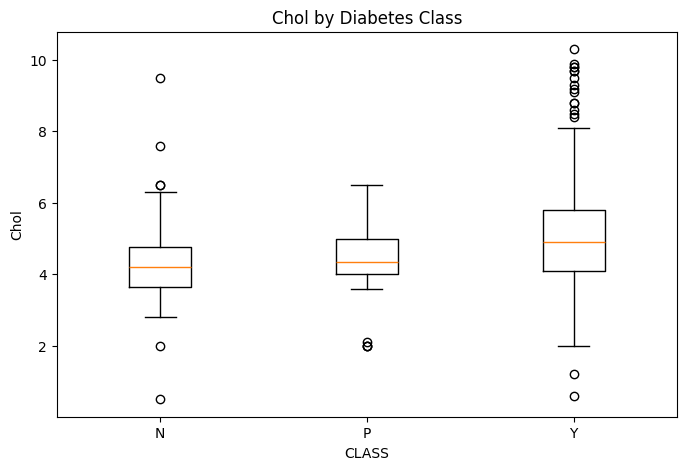

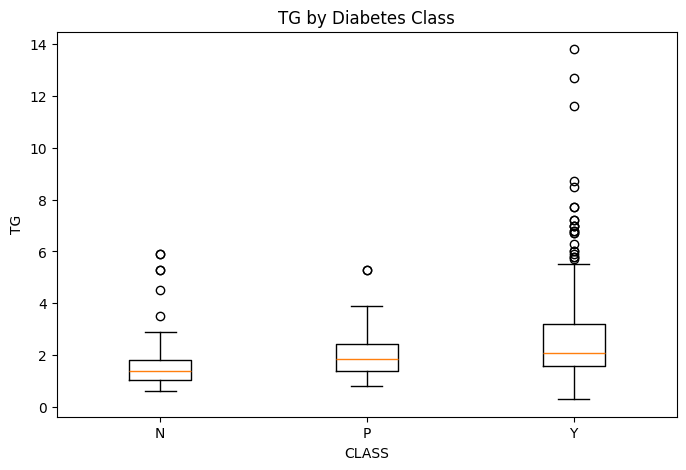

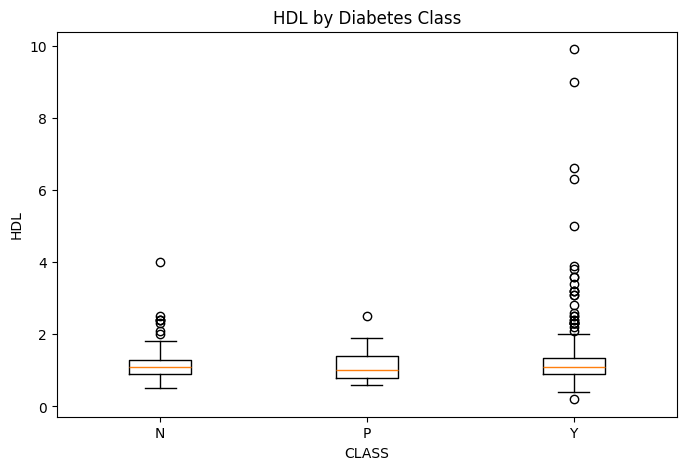

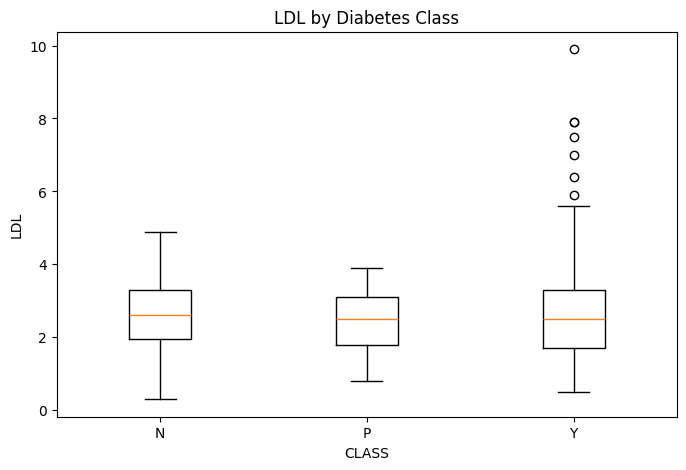

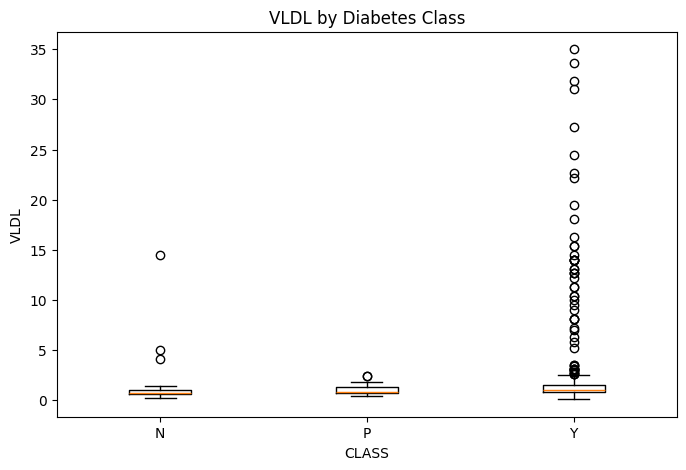

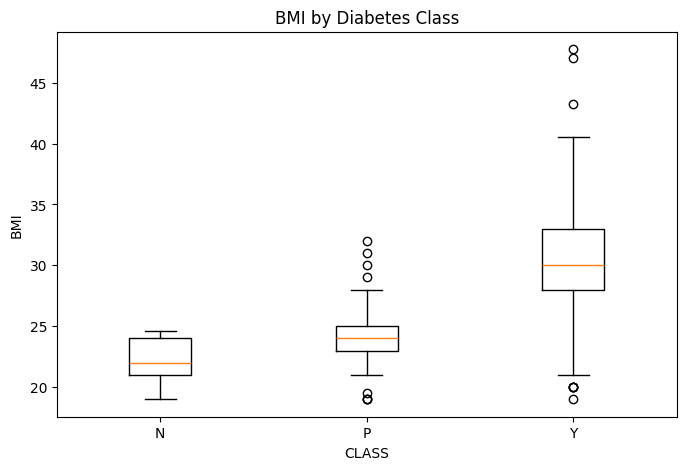

In [255]:
classes = sorted(df['CLASS'].unique())
for col in numeric_cols:
    data = [df[df['CLASS'] == cls][col] for cls in classes]
    plt.figure(figsize=(8, 5))
    plt.boxplot(data, tick_labels=classes) 
    
    plt.title(f"{col} by Diabetes Class")
    plt.xlabel("CLASS")
    plt.ylabel(col)
    plt.show()

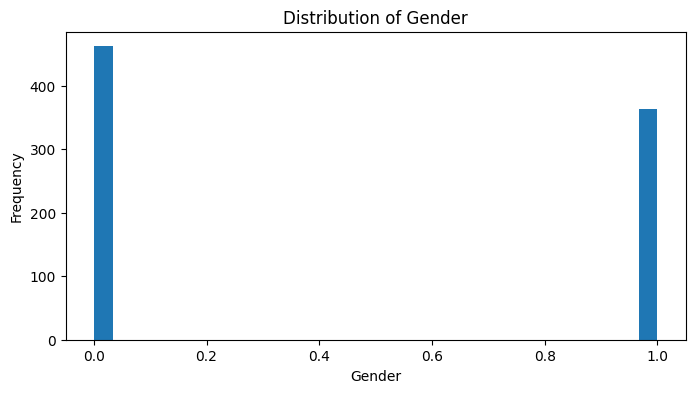

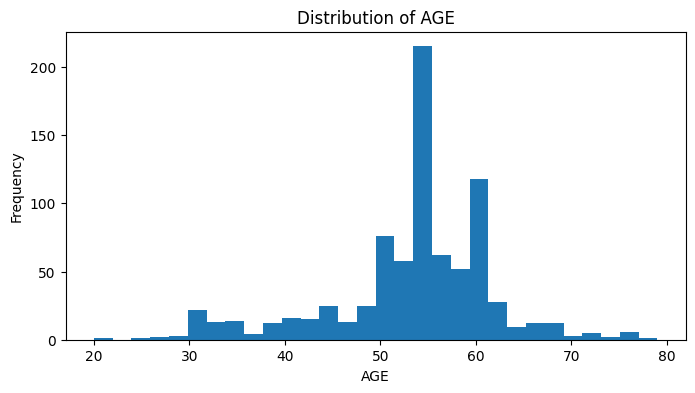

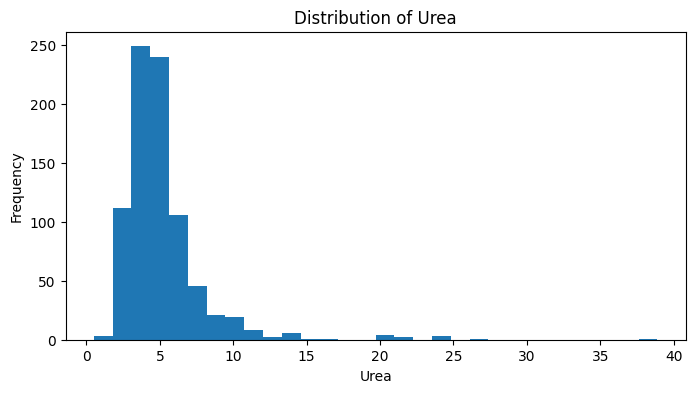

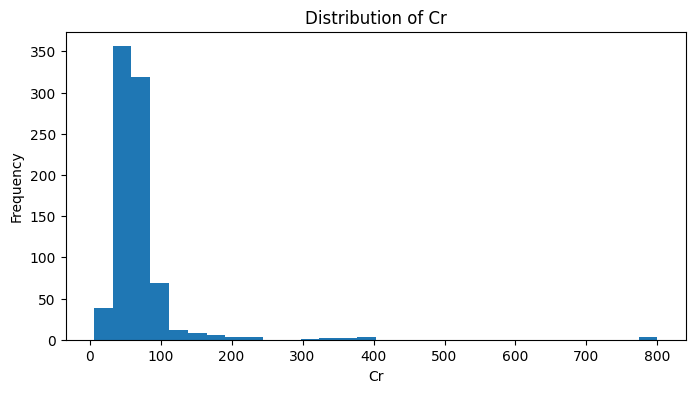

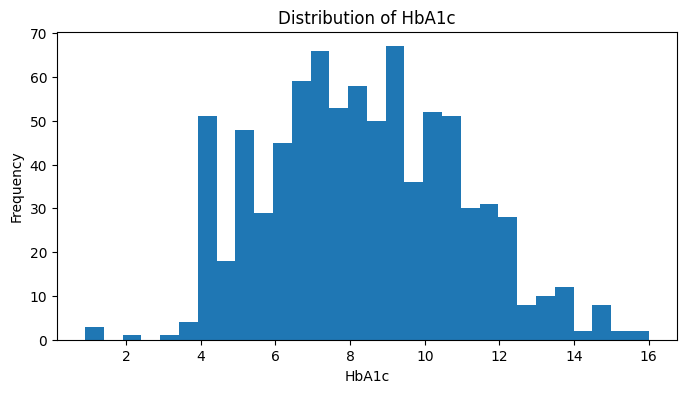

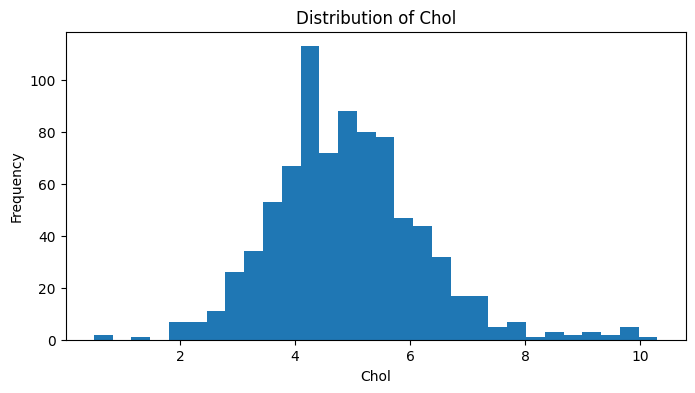

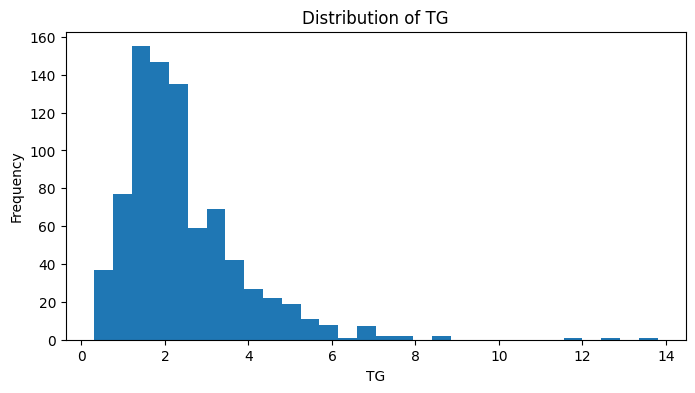

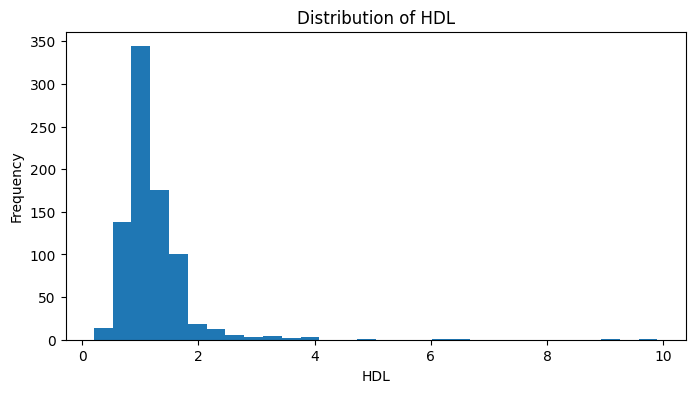

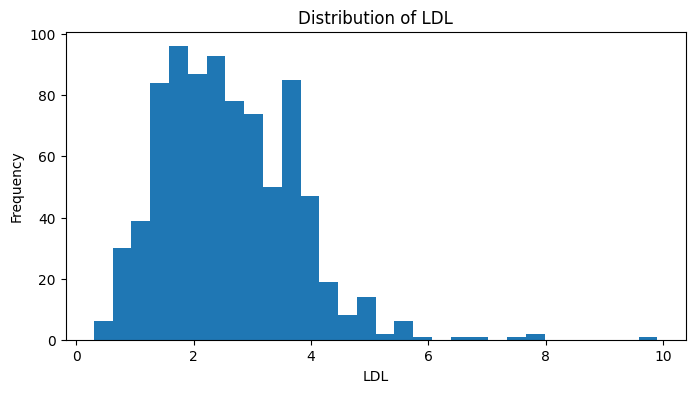

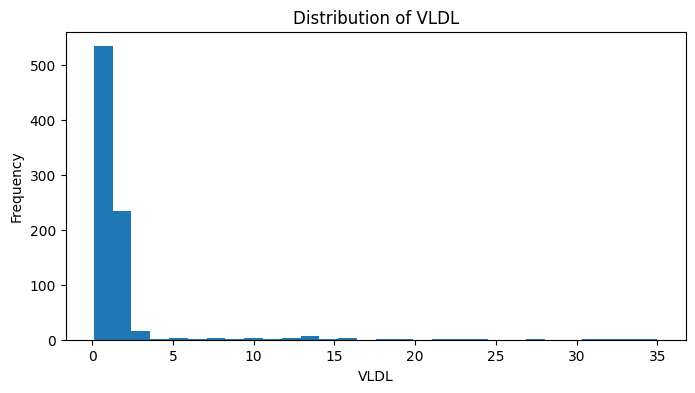

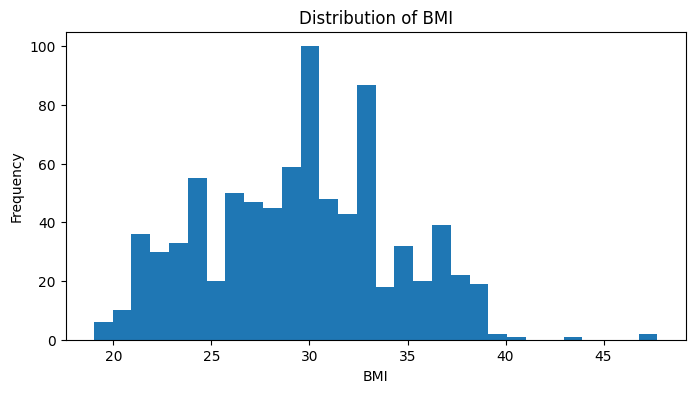

In [256]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

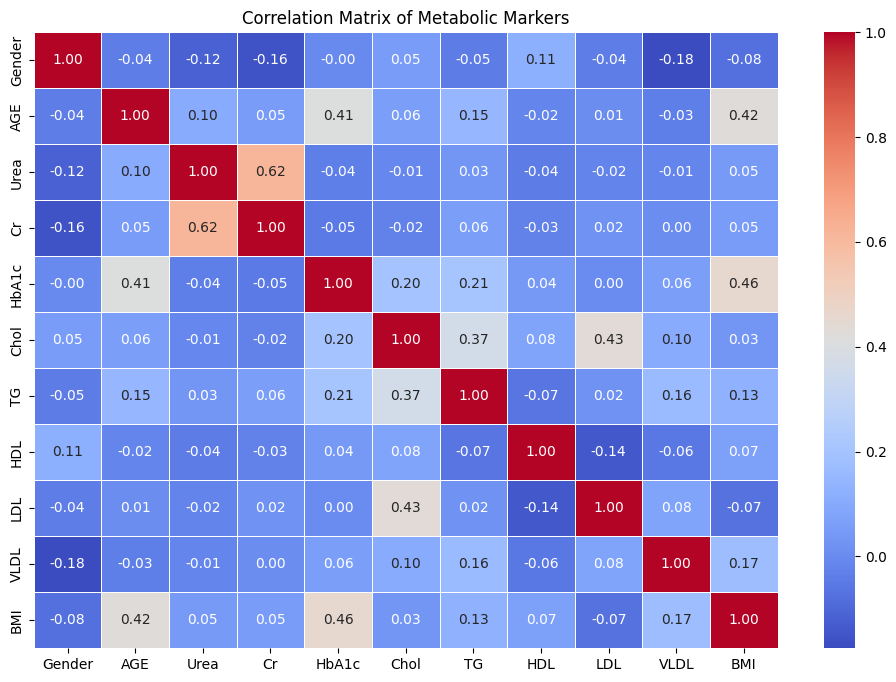

In [257]:
plt.figure(figsize=(12, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Metabolic Markers")
plt.show()

## 5. Model building and training

Create the target and feature variables, split the dataset, standardize inputs, and train several classifiers along with an artificial neural network for comparison.


In [258]:
Y = df['CLASS']
X = df.drop(columns=['CLASS'], axis=1)

In [259]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [260]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [261]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [262]:
nn_model = Sequential([
    Input(shape=(x_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(24, activation='relu'),
    Dropout(0.1),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(len(encoder.classes_), activation='softmax')
])

In [263]:
nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [264]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [265]:
class_labels = np.unique(y_train_encoded)
weights = compute_class_weight(class_weight='balanced', classes=class_labels, y=y_train_encoded)
class_weights = dict(zip(class_labels, weights))

In [281]:
print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(2.8947368421052633), np.int64(1): np.float64(6.875), np.int64(2): np.float64(0.39855072463768115)}


In [266]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ),
    "Support Vector Machine": SVC(
        class_weight=class_weights,
        random_state=42
    ),
    "ANN": nn_model
}

## 6. Classification results

Evaluate the trained classifiers using accuracy and macro-average metrics, and review confusion matrices and performance comparisons to identify the strongest model.


In [ ]:
results = []
trained_models = {}

for name, model in models.items():
    if name in ["Logistic Regression", "Support Vector Machine"]:
        model.fit(x_train_scaled, y_train_encoded)
        y_pred = model.predict(x_test_scaled)
    
    elif name == "ANN":
        model.fit(
            x_train_scaled, 
            y_train_encoded,
            epochs=100, 
            batch_size=32, 
            validation_split=0.2, 
            callbacks=[early_stopping],
            class_weight=class_weights,
            verbose=0
        )
        y_pred_probs = model.predict(x_test_scaled, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
    else:
        model.fit(x_train, y_train_encoded)
        y_pred = model.predict(x_test)
    
    trained_models[name] = model
    accuracy = accuracy_score(y_test_encoded, y_pred)
    
    classification_rep = classification_report(
        y_test_encoded, 
        y_pred, 
        target_names=encoder.classes_, 
        output_dict=True, 
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Classification Report": classification_rep
    })

In [268]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="Accuracy", ascending=False
)

print("Model Performance")
print(
    results_df[["Model", "Accuracy"]].to_string(
        index=False,
        formatters={"Accuracy": "{:.2%}".format}
    )
)

for _, row in results_df.iterrows():
    print(f"\n{row['Model']} - Classification Report")
    report_df = pd.DataFrame(row["Classification Report"]).T
    print(report_df.to_string(float_format="{:.3f}".format))

Model Performance
                 Model Accuracy
         Random Forest   98.18%
                   ANN   93.33%
Support Vector Machine   92.73%
   Logistic Regression   91.52%

Random Forest - Classification Report
              precision  recall  f1-score  support
N                 1.000   0.947     0.973   19.000
P                 1.000   0.750     0.857    8.000
Y                 0.979   1.000     0.989  138.000
accuracy          0.982   0.982     0.982    0.982
macro avg         0.993   0.899     0.940  165.000
weighted avg      0.982   0.982     0.981  165.000

ANN - Classification Report
              precision  recall  f1-score  support
N                 0.789   0.789     0.789   19.000
P                 0.545   0.750     0.632    8.000
Y                 0.985   0.964     0.974  138.000
accuracy          0.933   0.933     0.933    0.933
macro avg         0.773   0.834     0.798  165.000
weighted avg      0.941   0.933     0.936  165.000

Support Vector Machine - Classification

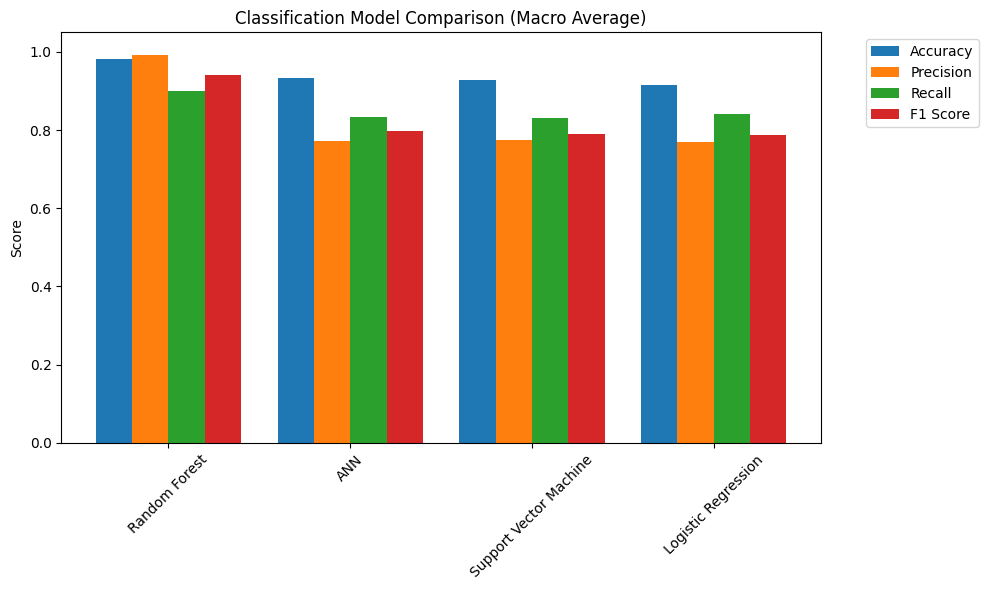

In [269]:
results_df['Precision'] = results_df['Classification Report'].apply(lambda x: x['macro avg']['precision'])
results_df['Recall'] = results_df['Classification Report'].apply(lambda x: x['macro avg']['recall'])
results_df['F1-Score'] = results_df['Classification Report'].apply(lambda x: x['macro avg']['f1-score'])

plt.figure(figsize=(10, 6))

x_coord = np.arange(len(results_df))
width = 0.2

plt.bar(
    x_coord - 1.5 * width,
    results_df['Accuracy'],
    width,
    label='Accuracy'
)

plt.bar(
    x_coord - 0.5 * width,
    results_df['Precision'],
    width,
    label='Precision'
)

plt.bar(
    x_coord + 0.5 * width,
    results_df['Recall'],
    width,
    label='Recall'
)

plt.bar(
    x_coord + 1.5 * width,
    results_df['F1-Score'],
    width,
    label='F1 Score'
)

plt.xticks(
    x_coord,
    results_df['Model'],
    rotation=45
)

plt.ylabel("Score")
plt.title("Classification Model Comparison (Macro Average)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.ylim(0, 1.05)
plt.tight_layout()

plt.show()

In [270]:
predictions = {}

for name, model in trained_models.items():
    if name in ["Logistic Regression", "Support Vector Machine"]:
        y_pred_int = model.predict(x_test_scaled)
        
    elif name == "ANN":
        y_pred_probs = model.predict(x_test_scaled, verbose=0)
        y_pred_int = np.argmax(y_pred_probs, axis=1)
        
    else:
        y_pred_int = model.predict(x_test)
    
    y_pred = encoder.inverse_transform(y_pred_int)
    
    predictions[name] = y_pred

In [271]:
for name, y_pred in predictions.items():
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           N       0.94      0.84      0.89        19
           P       0.40      0.75      0.52         8
           Y       0.97      0.93      0.95       138

    accuracy                           0.92       165
   macro avg       0.77      0.84      0.79       165
weighted avg       0.94      0.92      0.92       165


Random Forest Classification Report:
              precision    recall  f1-score   support

           N       1.00      0.95      0.97        19
           P       1.00      0.75      0.86         8
           Y       0.98      1.00      0.99       138

    accuracy                           0.98       165
   macro avg       0.99      0.90      0.94       165
weighted avg       0.98      0.98      0.98       165


Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           N       0.88      0.79      0.83        19


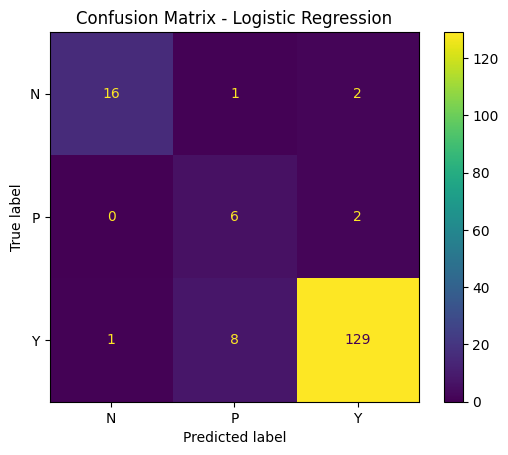

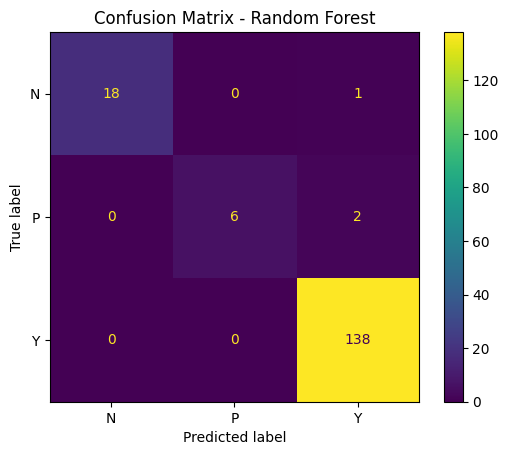

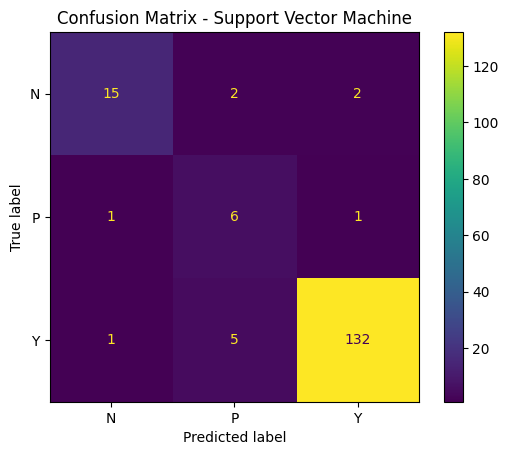

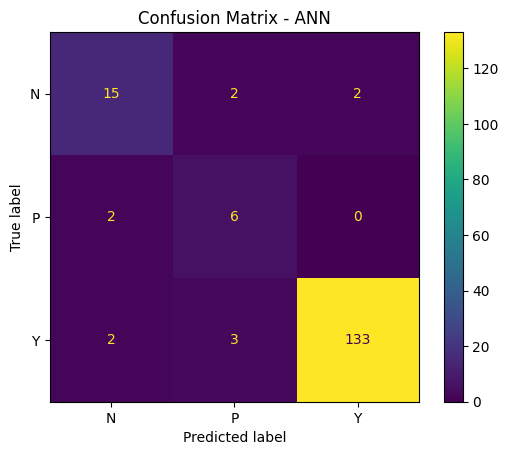

In [272]:
for name, y_pred in predictions.items():
    
    conf_mat = confusion_matrix(y_test, y_pred, labels=sorted(Y.unique()))
    conf_mat_disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=sorted(Y.unique()))
    
    conf_mat_disp.plot() 
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [273]:
rf_model = trained_models["Random Forest"]

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

HbA1c     0.461865
BMI       0.188263
AGE       0.141942
Chol      0.043824
TG        0.037433
Urea      0.029577
VLDL      0.025113
Cr        0.023544
LDL       0.020538
HDL       0.017583
Gender    0.010316
dtype: float64


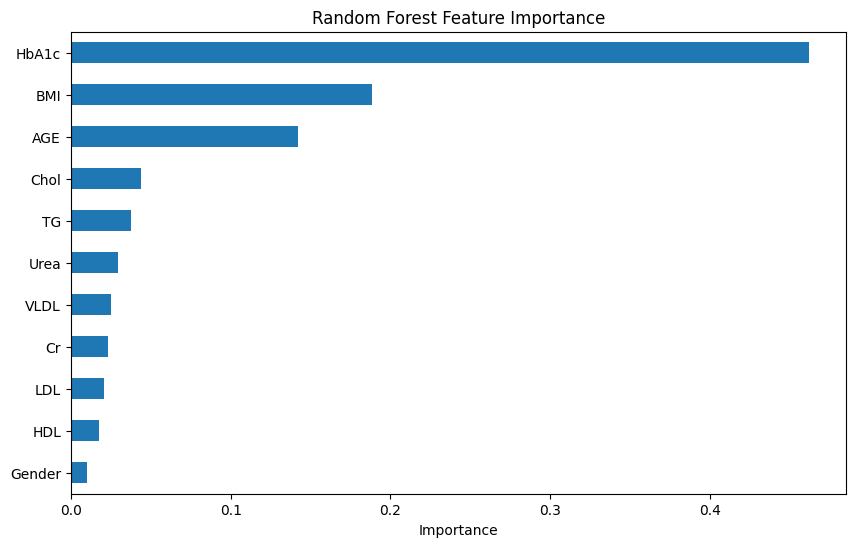

In [274]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(
    kind='barh'
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.show()

## 7. Clustering

Reduce dimensionality with PCA and apply unsupervised learning algorithms to identify latent groups in the diabetes data without using the class labels.


In [275]:
x_scaled_full = scaler.fit_transform(X) 
y_encoded_full = encoder.fit_transform(Y)

In [276]:
pca_full = PCA()
pca_full.fit(x_scaled_full)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
variance_threshold = 0.90
best_n_components = np.argmax(cumulative_variance >= variance_threshold) + 1

print(f"Optimal number of components for {variance_threshold*100}% variance: {best_n_components}")


pca_final = PCA(n_components=best_n_components)
X_pca = pca_final.fit_transform(x_scaled_full)

print(f"Original Data Shape: {x_scaled_full.shape}")
print(f"Reduced PCA Data Shape: {X_pca.shape}")
print(f"Exact Variance Retained: {np.sum(pca_final.explained_variance_ratio_) * 100:.2f}%")

Optimal number of components for 90.0% variance: 9
Original Data Shape: (825, 11)
Reduced PCA Data Shape: (825, 9)
Exact Variance Retained: 93.08%


In [277]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_clusters = kmeans.fit_predict(X_pca)

agglo = AgglomerativeClustering(n_clusters=3)
agglo_clusters = agglo.fit_predict(X_pca)

hdb = HDBSCAN(min_cluster_size=15)
hdb_clusters = hdb.fit_predict(X_pca)


## 8. Clustering results

Measure cluster quality using Adjusted Rand Index and Normalized Mutual Information to compare how well each clustering algorithm aligns with the known class labels.


In [278]:
clustering_results = [
    {
        "Algorithm": "K-Means",
        "ARI Score": adjusted_rand_score(y_encoded_full, kmeans_clusters),
        "NMI Score": normalized_mutual_info_score(y_encoded_full, kmeans_clusters)
    },
    {
        "Algorithm": "Agglomerative",
        "ARI Score": adjusted_rand_score(y_encoded_full, agglo_clusters),
        "NMI Score": normalized_mutual_info_score(y_encoded_full, agglo_clusters)
    },
    {
        "Algorithm": "HDBSCAN",
        "ARI Score": adjusted_rand_score(y_encoded_full, hdb_clusters),
        "NMI Score": normalized_mutual_info_score(y_encoded_full, hdb_clusters)
    }
]

cluster_df = pd.DataFrame(clustering_results)
print("Clustering Algorithm Performance")
print(cluster_df.to_string(index=False, float_format="{:.3f}".format))

Clustering Algorithm Performance
    Algorithm  ARI Score  NMI Score
      K-Means      0.204      0.305
Agglomerative      0.537      0.348
      HDBSCAN      0.004      0.012


## 9. Classification vs clustering comparison

Compare supervised and unsupervised approaches side by side to understand their differences in performance and how clustering structure relates to the labeled diabetes classes.


Classification Performance


,Model,Accuracy,F1-Score
1,Random Forest,98.18%,0.940
3,ANN,93.33%,0.798
2,Support Vector Machine,92.73%,0.791
0,Logistic Regression,91.52%,0.788


Clustering Performance


,Algorithm,ARI Score,NMI Score
0,K-Means,0.204,0.305
1,Agglomerative,0.537,0.348
2,HDBSCAN,0.004,0.012


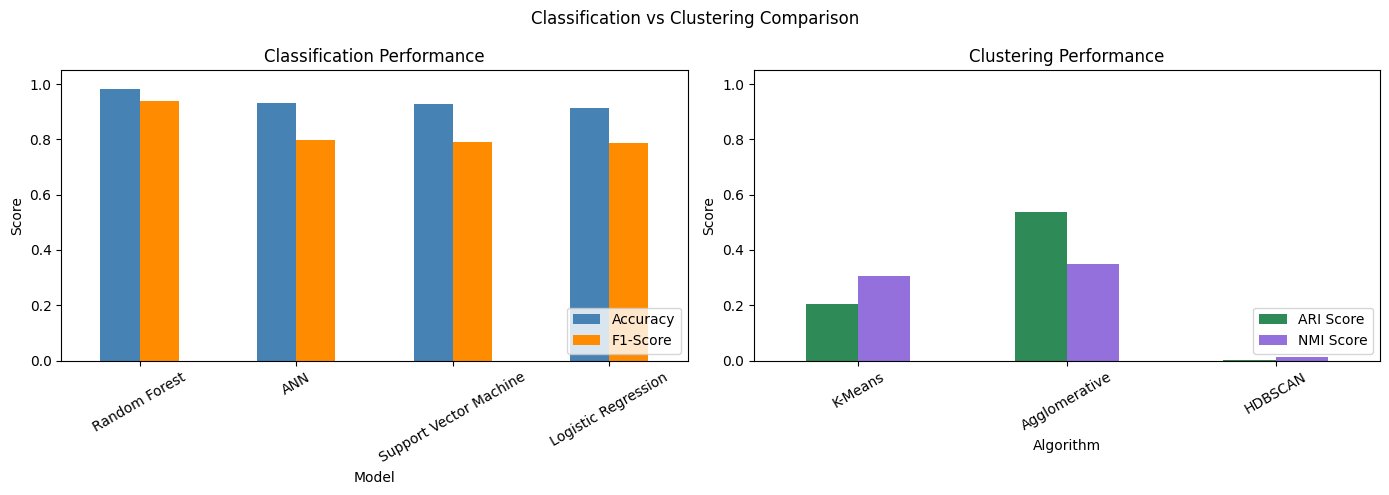

Best classifier: Random Forest (98.18% accuracy)
Best clustering algorithm by ARI: Agglomerative (0.537 ARI)


In [279]:
# Classification vs Clustering Comparison

classification_summary = results_df[
    ["Model", "Accuracy", "F1-Score"]
].copy()

clustering_summary = cluster_df[
    ["Algorithm", "ARI Score", "NMI Score"]
].copy()

print("Classification Performance")
display(
    classification_summary.style.format({
        "Accuracy": "{:.2%}",
        "F1-Score": "{:.3f}"
    })
)

print("Clustering Performance")
display(
    clustering_summary.style.format({
        "ARI Score": "{:.3f}",
        "NMI Score": "{:.3f}"
    })
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classification_summary.set_index("Model")[["Accuracy", "F1-Score"]].plot(
    kind="bar",
    ax=axes[0],
    ylim=(0, 1.05),
    color=["steelblue", "darkorange"]
)
axes[0].set_title("Classification Performance")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(loc="lower right")

clustering_summary.set_index("Algorithm")[["ARI Score", "NMI Score"]].plot(
    kind="bar",
    ax=axes[1],
    ylim=(0, 1.05),
    color=["seagreen", "mediumpurple"]
)
axes[1].set_title("Clustering Performance")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(loc="lower right")

plt.suptitle("Classification vs Clustering Comparison")
plt.tight_layout()
plt.show()

best_classifier = classification_summary.loc[
    classification_summary["Accuracy"].idxmax()
]
best_cluster = clustering_summary.loc[
    clustering_summary["ARI Score"].idxmax()
]

print(f"Best classifier: {best_classifier['Model']} "
      f"({best_classifier['Accuracy']:.2%} accuracy)")
print(f"Best clustering algorithm by ARI: {best_cluster['Algorithm']} "
      f"({best_cluster['ARI Score']:.3f} ARI)")


## 10. Error analysis

Inspect incorrect predictions to identify which patient patterns are hardest for the classifier and which features contribute most to misclassification.



Misclassifications involving the 'P' (Predict-diabetic) class: 2 cases
     HbA1c   BMI Actual Predicted
155    6.3  27.0      P         Y
148    5.8  32.0      P         Y


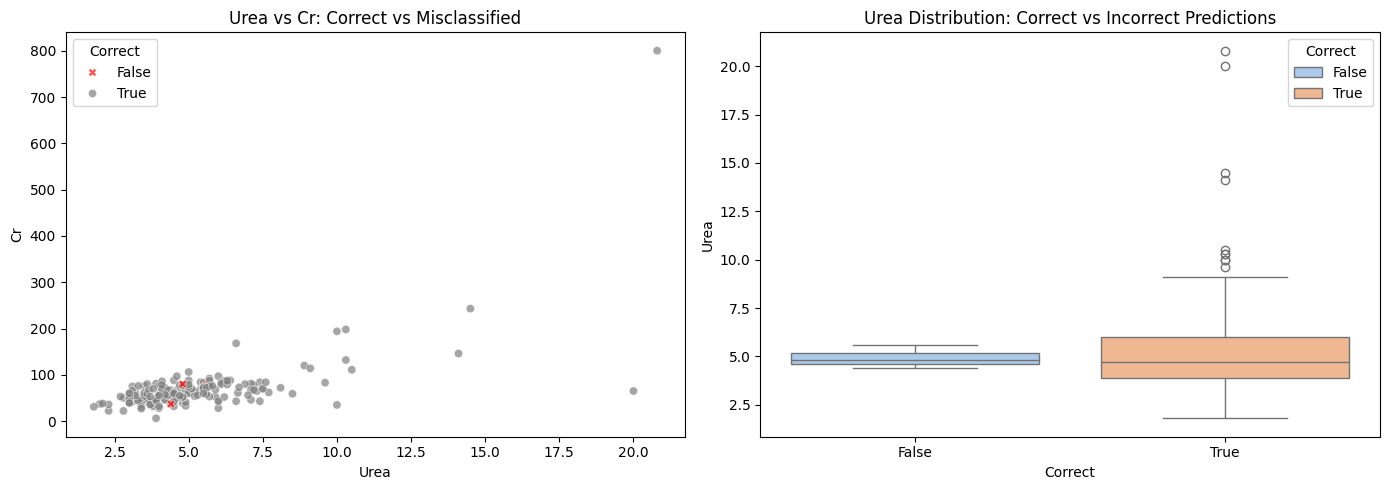

In [280]:
best_model_name = "Random Forest"
rf_pred = encoder.inverse_transform(trained_models[best_model_name].predict(x_test))

error_df = x_test.copy()
error_df['Actual'] = y_test
error_df['Predicted'] = rf_pred
error_df['Correct'] = error_df['Actual'] == error_df['Predicted']

p_confusions = error_df[
    (~error_df['Correct']) & 
    ((error_df['Actual'] == 'P') | (error_df['Predicted'] == 'P'))
]

print(f"\nMisclassifications involving the 'P' (Predict-diabetic) class: {len(p_confusions)} cases")
print(p_confusions[['HbA1c', 'BMI', 'Actual', 'Predicted']].head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x='Urea', y='Cr', 
    hue='Correct', 
    palette={True: 'gray', False: 'red'}, 
    style='Correct', markers={True: 'o', False: 'X'}, 
    data=error_df, ax=axes[0], alpha=0.7
)
axes[0].set_title("Urea vs Cr: Correct vs Misclassified")

sns.boxplot(x='Correct', y='Urea', data=error_df, ax=axes[1], palette='pastel', hue='Correct')
axes[1].set_title("Urea Distribution: Correct vs Incorrect Predictions")

plt.tight_layout()
plt.show()